GURU PRASAD N 24BAD029

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.optimizers import SGD, RMSprop, Adam

# Load and preprocess the MNIST dataset
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()
X_train, X_test = X_train / 255.0, X_test / 255.0  # Normalize pixel values to [0, 1]

print("Dataset Loaded Successfully.")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Dataset Loaded Successfully.


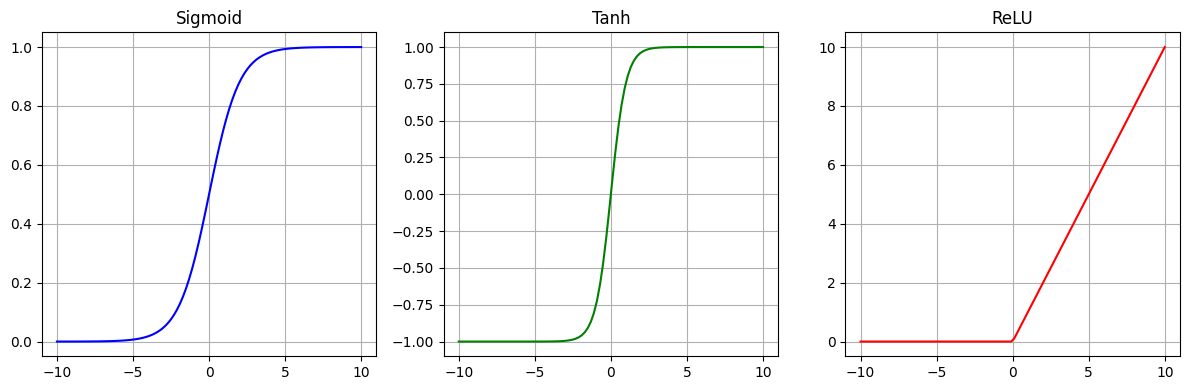

Nitheeswaran M 24BAD079


In [2]:
x = np.linspace(-10, 10, 100)
sigmoid = 1 / (1 + np.exp(-x))
tanh = np.tanh(x)
relu = np.maximum(0, x)

plt.figure(figsize=(12, 4))

# Sigmoid Plot
plt.subplot(1, 3, 1)
plt.plot(x, sigmoid, label="Sigmoid", color='blue')
plt.title("Sigmoid")
plt.grid(True)

# Tanh Plot
plt.subplot(1, 3, 2)
plt.plot(x, tanh, label="Tanh", color='green')
plt.title("Tanh")
plt.grid(True)

# ReLU Plot
plt.subplot(1, 3, 3)
plt.plot(x, relu, label="ReLU", color='red')
plt.title("ReLU")
plt.grid(True)

plt.tight_layout()
plt.show()
print("Nitheeswaran M 24BAD079")

**Activation Function Comparison**


**Sigmoid:**

* Output range: [0,1]
* Saturation/Gradient: Saturates at extremes (kills gradients), leading to the vanishing gradient problem.
* Efficiency: Computationally expensive due to the exponential function.
* Applications: Binary classification output layers.


**Tanh:**

* Output range: [−1,1]
* Saturation/Gradient: Zero-centered, which helps optimization, but still suffers from vanishing gradients at extremes.
* Efficiency: Computationally expensive.
* Applications: Hidden layers in recurrent neural networks (RNNs).


**ReLU:** 
* f(x)=max(0,x)
* Output range: [0,∞)
* Saturation/Gradient: Does not saturate in the positive region (gradient is 1), solving the vanishing gradient problem.
* Gradient is 0 for negative values (dying ReLU problem).
* Efficiency: Highly computationally efficient (simple thresholding).
* Applications: Default activation function for hidden layers in modern deep learning (CNNs, MLPs).    



Training with SIGMOID activation:


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
2026-08-24 14:50:16.082267: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


SIGMOID -> Final Train Acc: 0.9900 | Final Val Acc: 0.9772

Training with TANH activation:
TANH -> Final Train Acc: 0.9954 | Final Val Acc: 0.9765

Training with RELU activation:
RELU -> Final Train Acc: 0.9940 | Final Val Acc: 0.9747


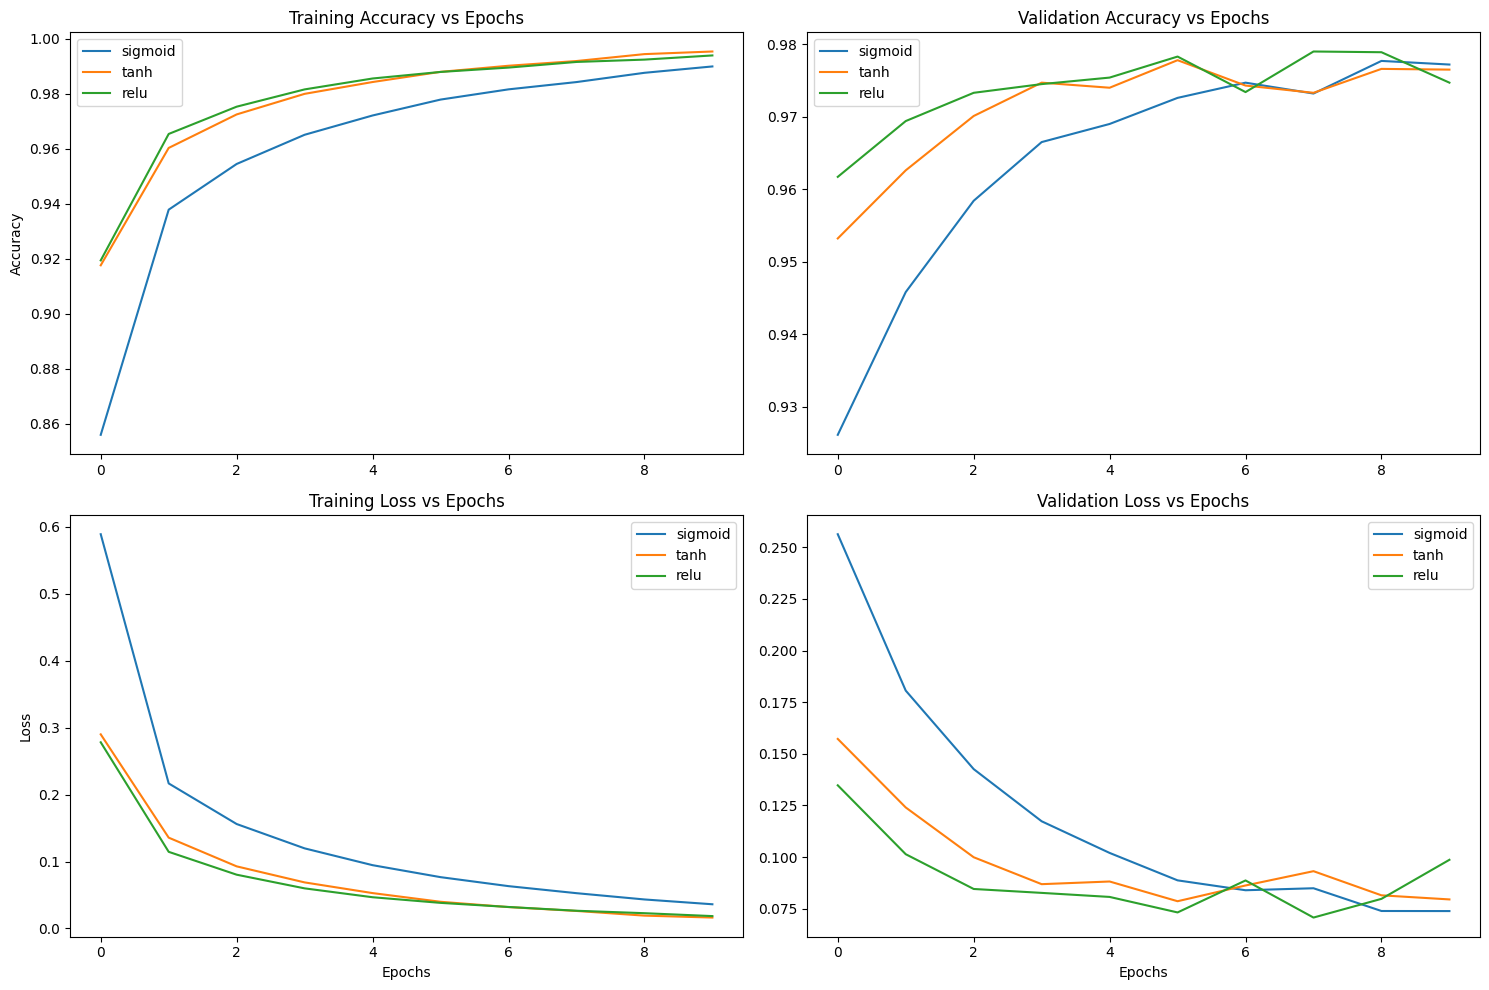

Nitheeswaran M 24BAD079


In [3]:
def build_model(activation_function):
    model = Sequential([
        Flatten(input_shape=(28, 28)),
        Dense(128, activation=activation_function),
        Dense(64, activation=activation_function),
        Dense(10, activation='softmax')
    ])
    model.compile(optimizer='adam', 
                  loss='sparse_categorical_crossentropy', 
                  metrics=['accuracy'])
    return model

activations = ['sigmoid', 'tanh', 'relu']
history_dict_activations = {}

for act in activations:
    print(f"\nTraining with {act.upper()} activation:")
    model = build_model(act)
    history = model.fit(X_train, y_train, epochs=10, validation_data=(X_test, y_test), batch_size=64, verbose=0) 
    history_dict_activations[act] = history.history
    
    final_train_acc = history.history['accuracy'][-1]
    final_val_acc = history.history['val_accuracy'][-1]
    print(f"{act.upper()} -> Final Train Acc: {final_train_acc:.4f} | Final Val Acc: {final_val_acc:.4f}")

fig, axs = plt.subplots(2, 2, figsize=(15, 10))

for act in activations:
    # Plot Training Accuracy
    axs[0, 0].plot(history_dict_activations[act]['accuracy'], label=act)
    axs[0, 0].set_title('Training Accuracy vs Epochs')
    axs[0, 0].set_ylabel('Accuracy')
    axs[0, 0].legend()

    # Plot Validation Accuracy
    axs[0, 1].plot(history_dict_activations[act]['val_accuracy'], label=act)
    axs[0, 1].set_title('Validation Accuracy vs Epochs')
    axs[0, 1].legend()

    # Plot Training Loss
    axs[1, 0].plot(history_dict_activations[act]['loss'], label=act)
    axs[1, 0].set_title('Training Loss vs Epochs')
    axs[1, 0].set_ylabel('Loss')
    axs[1, 0].set_xlabel('Epochs')
    axs[1, 0].legend()

    # Plot Validation Loss
    axs[1, 1].plot(history_dict_activations[act]['val_loss'], label=act)
    axs[1, 1].set_title('Validation Loss vs Epochs')
    axs[1, 1].set_xlabel('Epochs')
    axs[1, 1].legend()

plt.tight_layout()
plt.show()
print("Nitheeswaran M 24BAD079")

**Task B Analysis & Justification**


Best Performer: ReLU consistently performs the best, achieving the highest training and validation accuracy in the fewest epochs.


**Justification:**

* Sigmoid suffers heavily from the vanishing gradient problem. Its outputs saturate near 0 or 1, causing the gradients to become incredibly small, making weight updates painfully slow. This is why its accuracy curve rises much slower than the others.
* Tanh performs better than Sigmoid because it is zero-centered (range -1 to 1), allowing for stronger gradients and faster convergence early on. However, it still eventually saturates at the extremes.
* ReLU solves the vanishing gradient problem for positive values by maintaining a constant gradient of 1. This allows the network to learn much faster (fewer epochs to converge) and reach a lower final loss compared to Sigmoid and Tanh.



--- Training with SGD optimizer ---
SGD -> Final Train Acc: 0.9499 | Final Val Acc: 0.9508

--- Training with Momentum optimizer ---
Momentum -> Final Train Acc: 0.9912 | Final Val Acc: 0.9778

--- Training with RMSprop optimizer ---
RMSprop -> Final Train Acc: 0.9934 | Final Val Acc: 0.9769

--- Training with Adam optimizer ---
Adam -> Final Train Acc: 0.9942 | Final Val Acc: 0.9707


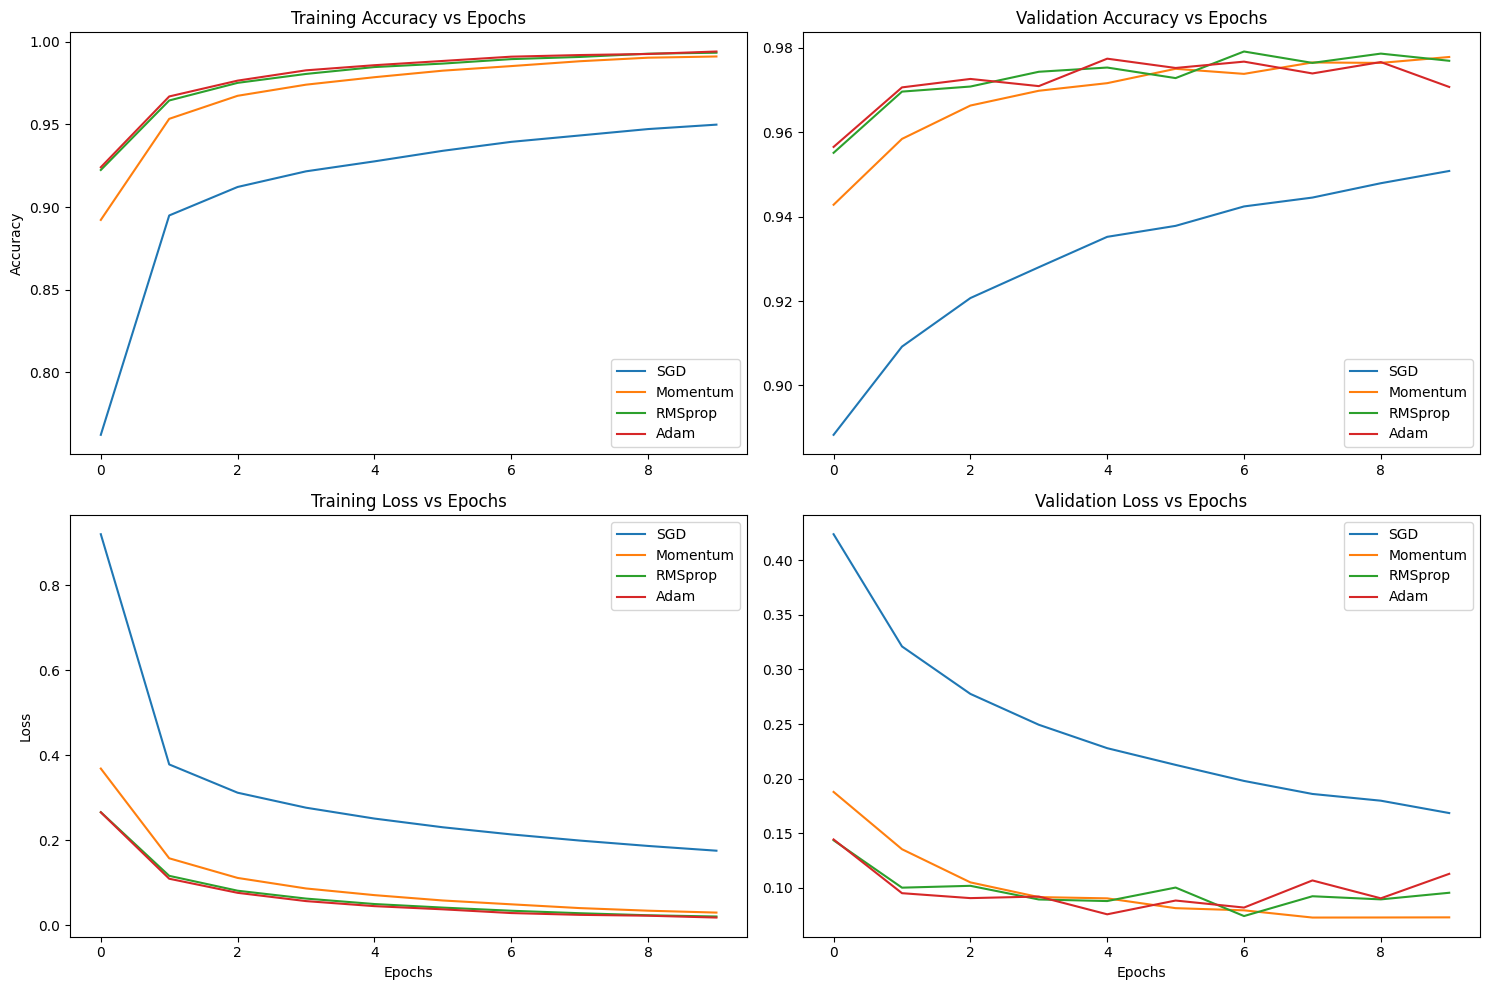

Nitheeswaran M 24BAD079


In [4]:
def build_model_opt():
    model = Sequential([
        Flatten(input_shape=(28, 28)),
        Dense(128, activation='relu'), 
        Dense(64, activation='relu'),
        Dense(10, activation='softmax')
    ])
    return model

optimizers = {
    'SGD': SGD(learning_rate=0.01),
    'Momentum': SGD(learning_rate=0.01, momentum=0.9),
    'RMSprop': RMSprop(learning_rate=0.001),
    'Adam': Adam(learning_rate=0.001)
}

history_dict_opt = {}

for opt_name, opt in optimizers.items():
    print(f"\n--- Training with {opt_name} optimizer ---")
    model = build_model_opt()
    model.compile(optimizer=opt, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    history = model.fit(X_train, y_train, epochs=10, validation_data=(X_test, y_test), batch_size=64, verbose=0)
    history_dict_opt[opt_name] = history.history
    
    final_train_acc = history.history['accuracy'][-1]
    final_val_acc = history.history['val_accuracy'][-1]
    print(f"{opt_name} -> Final Train Acc: {final_train_acc:.4f} | Final Val Acc: {final_val_acc:.4f}")

# Visualizing Optimizer Performance
fig, axs = plt.subplots(2, 2, figsize=(15, 10))

for opt_name in optimizers.keys():
    # Training Accuracy
    axs[0, 0].plot(history_dict_opt[opt_name]['accuracy'], label=opt_name)
    axs[0, 0].set_title('Training Accuracy vs Epochs')
    axs[0, 0].set_ylabel('Accuracy')
    axs[0, 0].legend()

    # Validation Accuracy
    axs[0, 1].plot(history_dict_opt[opt_name]['val_accuracy'], label=opt_name)
    axs[0, 1].set_title('Validation Accuracy vs Epochs')
    axs[0, 1].legend()

    # Training Loss
    axs[1, 0].plot(history_dict_opt[opt_name]['loss'], label=opt_name)
    axs[1, 0].set_title('Training Loss vs Epochs')
    axs[1, 0].set_ylabel('Loss')
    axs[1, 0].set_xlabel('Epochs')
    axs[1, 0].legend()

    # Validation Loss
    axs[1, 1].plot(history_dict_opt[opt_name]['val_loss'], label=opt_name)
    axs[1, 1].set_title('Validation Loss vs Epochs')
    axs[1, 1].set_xlabel('Epochs')
    axs[1, 1].legend()

plt.tight_layout()
plt.show()
print("Nitheeswaran M 24BAD079")

**Task C Analysis & Discussion**



* **Convergence Speed:** Adam and RMSProp converge significantly faster than standard SGD. They dynamically adjust the learning rate for each parameter, allowing them to rapidly descend the loss landscape. Standard SGD is the slowest to converge because it updates weights uniformly without adapting to the gradient's history.
* **Momentum's Impact:** Adding Momentum to SGD drastically improves its convergence speed over vanilla SGD by accelerating gradients in the right direction and dampening oscillations.
* **Generalization and Final Accuracy:** Adam generally yields the best balance of speed and final validation accuracy in this experiment. While standard SGD is slower, if trained for many more epochs, it can sometimes generalize slightly better than Adam on unseen data. However, within a practical timeframe (10 epochs), Adam rapidly dominates by achieving high validation accuracy and low validation loss.


In [5]:
import os

save_path = '/kaggle/working/DL_Experiments'
os.makedirs(save_path, exist_ok=True)

model.save(f'{save_path}/best_mnist_model.keras')
print(f"\nModel successfully saved to Kaggle working directory: {save_path}/best_mnist_model.keras")
print("Nitheeswaran M 24BAD079")


Model successfully saved to Kaggle working directory: /kaggle/working/DL_Experiments/best_mnist_model.keras
Nitheeswaran M 24BAD079
